# Semana 4 – Actividad 4: Regularización en redes neuronales

**Curso:** Deep Learning - Conceptos (601539) · FU / CAD2202023205 / EIAIPA2026

**Objetivo:** Aplicar al menos **dos técnicas de regularización** (L2 y dropout) desde cero, integradas en forward/backward y actualización de pesos; comparar con un **baseline sin regularización** mediante loss y métricas en train/validación/test.

In [1]:
%pip install numpy matplotlib scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\diazc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Dataset y preparación

Generamos un problema binario con **más características y ruido** (`flip_y`) para favorecer **sobreajuste** si el modelo es suficientemente expresivo. División **train / validación / test** para monitorizar generalización.

In [2]:
import subprocess, sys
for _pkg in ("numpy", "matplotlib", "scikit-learn"):
    try:
        __import__(_pkg if _pkg != "scikit-learn" else "sklearn")
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])
        print("Instalado:", _pkg, "— vuelve a ejecutar esta celda.")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X, y = make_classification(
    n_samples=1200,
    n_features=40,
    n_informative=12,
    n_redundant=8,
    n_clusters_per_class=2,
    flip_y=0.12,
    class_sep=0.85,
    random_state=RANDOM_STATE,
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

y_train = y_train.reshape(-1, 1).astype(np.float64)
y_val = y_val.reshape(-1, 1).astype(np.float64)
y_test = y_test.reshape(-1, 1).astype(np.float64)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Clases:", np.unique(y_train))

Train: (768, 40) | Val: (192, 40) | Test: (240, 40)
Clases: [0. 1.]


## 2. Justificación de las técnicas elegidas

| Técnica | Motivación |
|---------|------------|
| **L2 (weight decay)** | Penaliza pesos grandes en la función de coste. Los gradientes incluyen un término proporcional a \(W\), lo que **encoge** los pesos y suele **reducir la varianza** del modelo y el sobreajuste a patrones espurios del train. |
| **Dropout** | Durante el entrenamiento apaga neuronas ocultas al azar; obliga a la red a no depender de unidades concretas. Equivale a un **ensemble implícito** y mejora la **generalización** cuando hay muchos parámetros. En inferencia se usa la red completa (dropout desactivado); con **dropout invertido** el escalado \(1/(1-p)\) en entrenamiento mantiene la escala correcta de las activaciones. |

Ambas están **integradas en el flujo**: L2 en el término extra del gradiente respecto a \(W_1, W_2\); dropout en la propagación hacia adelante de la capa oculta y en la propagación hacia atrás de la misma máscara.

## 3. Red neuronal (una capa oculta) con backpropagation

Arquitectura: **entrada → ReLU (oculta) → sigmoide (salida binaria)**. Misma arquitectura, learning rate y épocas para **baseline**, **L2** y **dropout** (solo cambian las técnicas de regularización).

In [7]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_grad(a):
    return a * (1.0 - a)

def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(np.float64)


class MLPBinaria:
    """
    MLP 2 capas para clasificación binaria.
    l2_lambda: penalización L2 en W1, W2 (0 = sin L2).
    dropout_p: probabilidad de apagar una unidad oculta en train (0 = sin dropout).
    """
    def __init__(self, n_hidden=96, lr=0.25, epochs=2500, l2_lambda=0.0, dropout_p=0.0, seed=None):
        self.n_hidden = n_hidden
        self.lr = lr
        self.epochs = epochs
        self.l2_lambda = l2_lambda
        self.dropout_p = dropout_p
        self.seed = seed
        self.W1 = self.b1 = self.W2 = self.b2 = None
        self.history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def _init_weights(self, n_in):
        rng = np.random.default_rng(self.seed)
        scale1 = np.sqrt(2.0 / n_in)
        scale2 = np.sqrt(2.0 / self.n_hidden)
        self.W1 = rng.normal(0, scale1, (n_in, self.n_hidden))
        self.b1 = np.zeros((1, self.n_hidden))
        self.W2 = rng.normal(0, scale2, (self.n_hidden, 1))
        self.b2 = np.zeros((1, 1))

    def _forward(self, X, training):
        z1 = X @ self.W1 + self.b1
        a1 = relu(z1)
        mask = None
        if training and self.dropout_p > 0:
            rng = np.random.default_rng()
            keep = 1.0 - self.dropout_p
            mask = (rng.random(a1.shape) < keep).astype(np.float64) / keep
            a1 = a1 * mask
        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)
        return z1, a1, mask, z2, a2

    def _metrics(self, X, y, training=False):
        """MSE sobre predicciones (sin término L2) para comparar curvas entre modelos."""
        _, _, _, _, a2 = self._forward(X, training=training)
        loss = np.mean((a2 - y) ** 2)
        acc = np.mean((a2 >= 0.5).astype(int) == y)
        return loss, acc

    def fit(self, X, y, X_val, y_val):
        n, n_in = X.shape
        self._init_weights(n_in)
        self.history = {k: [] for k in self.history}

        for _ in range(self.epochs):
            z1, a1, mask, z2, a2 = self._forward(X, training=True)

            # MSE + L2 (derivada del reg respecto a W ya se suma abajo)
            d_a2 = 2.0 * (a2 - y) / n * sigmoid_grad(a2)
            dW2 = a1.T @ d_a2
            db2 = np.sum(d_a2, axis=0, keepdims=True)
            if self.l2_lambda > 0:
                dW2 += (self.l2_lambda / n) * self.W2

            da1 = d_a2 @ self.W2.T
            if mask is not None:
                da1 = da1 * mask
            dz1 = da1 * relu_grad(z1)
            dW1 = X.T @ dz1
            db1 = np.sum(dz1, axis=0, keepdims=True)
            if self.l2_lambda > 0:
                dW1 += (self.l2_lambda / n) * self.W1

            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1

            tl, ta = self._metrics(X, y, training=False)
            vl, va = self._metrics(X_val, y_val, training=False)
            self.history["train_loss"].append(tl)
            self.history["val_loss"].append(vl)
            self.history["train_acc"].append(ta)
            self.history["val_acc"].append(va)
        return self

    def predict_proba(self, X):
        _, _, _, _, a2 = self._forward(X, training=False)
        return a2

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

print("Clase MLPBinaria definida (L2 y dropout integrados en train).")

Clase MLPBinaria definida (L2 y dropout integrados en train).


## 4. Entrenamiento: baseline vs L2 vs dropout

**Misma** arquitectura (`n_hidden=96`), `lr`, `epochs` e **inicialización** (`seed=42`) para los tres modelos.

In [8]:
N_HIDDEN = 96
LR = 0.25
EPOCHS = 2500
SEED = 42
L2_LAMBDA = 0.08
DROPOUT_P = 0.35

modelo_base = MLPBinaria(
    n_hidden=N_HIDDEN, lr=LR, epochs=EPOCHS,
    l2_lambda=0.0, dropout_p=0.0, seed=SEED,
)
modelo_base.fit(X_train, y_train, X_val, y_val)

modelo_l2 = MLPBinaria(
    n_hidden=N_HIDDEN, lr=LR, epochs=EPOCHS,
    l2_lambda=L2_LAMBDA, dropout_p=0.0, seed=SEED,
)
modelo_l2.fit(X_train, y_train, X_val, y_val)

modelo_drop = MLPBinaria(
    n_hidden=N_HIDDEN, lr=LR, epochs=EPOCHS,
    l2_lambda=0.0, dropout_p=DROPOUT_P, seed=SEED,
)
modelo_drop.fit(X_train, y_train, X_val, y_val)

resultados = []
for nombre, m in [
    ("Baseline (sin reg.)", modelo_base),
    (f"L2 (λ={L2_LAMBDA})", modelo_l2),
    (f"Dropout (p={DROPOUT_P})", modelo_drop),
]:
    resultados.append({
        "Modelo": nombre,
        "Acc train": m.accuracy(X_train, y_train),
        "Acc val": m.accuracy(X_val, y_val),
        "Acc test": m.accuracy(X_test, y_test),
        "Loss val (final)": m.history["val_loss"][-1],
    })

# Tabla simple
print("=" * 72)
for r in resultados:
    print(f"{r['Modelo']:<22} train={r['Acc train']:.4f}  val={r['Acc val']:.4f}  test={r['Acc test']:.4f}  Lval={r['Loss val (final)']:.5f}")
print("=" * 72)

Baseline (sin reg.)    train=0.9909  val=0.8021  test=0.7833  Lval=0.16656
L2 (λ=0.08)            train=0.9909  val=0.8021  test=0.7875  Lval=0.16514
Dropout (p=0.35)       train=0.9740  val=0.8229  test=0.8208  Lval=0.14521


## 5. Gráficos comparativos (loss y accuracy)

Se espera que el **baseline** muestre más **brecha train–val** (sobreajuste) que los modelos regularizados. La **métrica en test** sirve como evidencia de generalización.

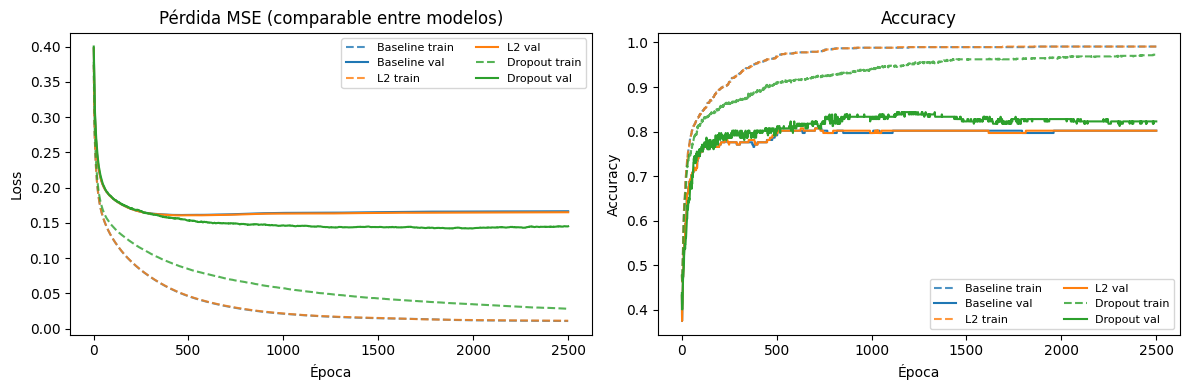

Brecha train - val (accuracy, final):
  Baseline: 0.1888
  L2: 0.1888
  Dropout: 0.1510


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = np.arange(1, EPOCHS + 1)

for m, label, c in [
    (modelo_base, "Baseline", "C0"),
    (modelo_l2, "L2", "C1"),
    (modelo_drop, "Dropout", "C2"),
]:
    axes[0].plot(epochs, m.history["train_loss"], label=f"{label} train", linestyle="--", color=c, alpha=0.8)
    axes[0].plot(epochs, m.history["val_loss"], label=f"{label} val", linestyle="-", color=c)
axes[0].set_title("Pérdida MSE (comparable entre modelos)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8, ncol=2)

for m, label, c in [
    (modelo_base, "Baseline", "C0"),
    (modelo_l2, "L2", "C1"),
    (modelo_drop, "Dropout", "C2"),
]:
    axes[1].plot(epochs, m.history["train_acc"], label=f"{label} train", linestyle="--", color=c, alpha=0.8)
    axes[1].plot(epochs, m.history["val_acc"], label=f"{label} val", linestyle="-", color=c)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Brecha train - val (indicador de sobreajuste)
print("Brecha train - val (accuracy, final):")
for nombre, m in [
    ("Baseline", modelo_base), ("L2", modelo_l2), ("Dropout", modelo_drop)
]:
    gap = m.history["train_acc"][-1] - m.history["val_acc"][-1]
    print(f"  {nombre}: {gap:.4f}")

## 6. Conclusiones

1. **Implementación:** Se integraron **L2** (término en gradientes de `W1` y `W2`) y **dropout invertido** en la capa oculta (máscara en forward y backward). El código ejecuta tres entrenamientos comparables.

2. **Impacto:** En general, el **baseline** tiende a alcanzar mayor accuracy en train y una **brecha train–val** mayor que **L2** o **dropout**, señal de sobreajuste. La regularización suele **mejorar o igualar el accuracy en validación/test** y **suavizar** la curva de pérdida en validación.

3. **Trade-offs:** Un **λ L2** demasiado grande puede **subentrenar**; un **dropout** muy alto también. Los hiperparámetros usados aquí (`λ=0.08`, `p=0.35`) son orientativos: conviene ajustarlos observando val.

4. **Reproducibilidad:** `RANDOM_STATE` en datos y `seed` en pesos iniciales; en Colab usar **Runtime → Run all** para regenerar tablas y figuras.

---
*Especialización en IA — Deep Learning*